# MLP 组件与决策边界实验室

**实验节奏：** 先预测 → 只替换一个组件 → 看图 → 解释 → 完成挑战  
**English keywords：** decision boundary, logits, activation, loss, optimizer, gradient norm

本 Notebook 是主要运行入口；独立启动说明、修改地图和实验记录模板见 `快速上手与练习指南.md`。模型、训练与绘图实现统一位于 `core.py`。

## 1. 学习目标

完成本实验后，你应该能：

1. 从决策边界判断 MLP 学到了怎样的分类规则；
2. 解释激活函数、损失函数、优化器、深度/宽度和 Dropout 的作用；
3. 知道为什么公平实验一次只能改变一个变量；
4. 联合阅读 loss、accuracy 与 gradient norm，而不是只看最终准确率；
5. 找到组件修改区，并在不改动训练与绘图代码的情况下扩展一个组件。

## 开始前：先确认修改位置

| 目标 | 修改位置 |
|---|---|
| 更换已有组件、深度、宽度或 Dropout | 本 Notebook 第 6 节 |
| 增加激活函数 | `core.py` → `_activation()` |
| 增加优化器 | `core.py` → `validate_config()`、`_make_optimizer()` |
| 修改网络层次 | `core.py` → `MLP` |
| 增加损失方案 | `core.py` → `_classification_loss()` |

`core.py` 已标出“可修改组件区”。首次运行不要改数据、训练记录和绘图部分。

In [2]:
# 本单元格只负责找到共享核心代码；从项目根目录或本目录启动都能运行。
from dataclasses import replace
from pathlib import Path
import sys
import torch

lab_dir = Path.cwd()
if not (lab_dir / 'core.py').exists():
    lab_dir = (Path.cwd() / '01_mlp_lab').resolve()
if str(lab_dir) not in sys.path:
    sys.path.insert(0, str(lab_dir))

from core import (
    base_config, make_dataset, plot_comparison, plot_dataset_gallery,
    plot_final_diagnosis, plot_training_story, print_result_table,
    run_comparison, train_experiment
)

DEVICE = 'cuda'    # CPU 使用 'cpu'；NVIDIA GPU 使用 'cuda'；不确定时可用 'auto'。
MODE = 'fast'     # 课堂使用 fast，课后可改为 extended。
DATASET = 'spiral'
SEED = 42
print(f'当前实验：device={DEVICE}, mode={MODE}, dataset={DATASET}, seed={SEED}')

当前实验：device=cuda, mode=fast, dataset=spiral, seed=42


## 2. 先看数据，不急着训练

**预测题（等待 20 秒）：** 月牙、同心圆、螺旋中，哪一种需要更复杂的决策边界？为什么一条直线不够？

> 我的预测：______________________________

<details><summary>完成预测后展开提示</summary>

三者都不是简单线性可分；螺旋的类别区域互相缠绕，通常需要更多非线性变换。图形看起来复杂不等于一定需要更大的网络，最终还要结合噪声和样本数量。

</details>

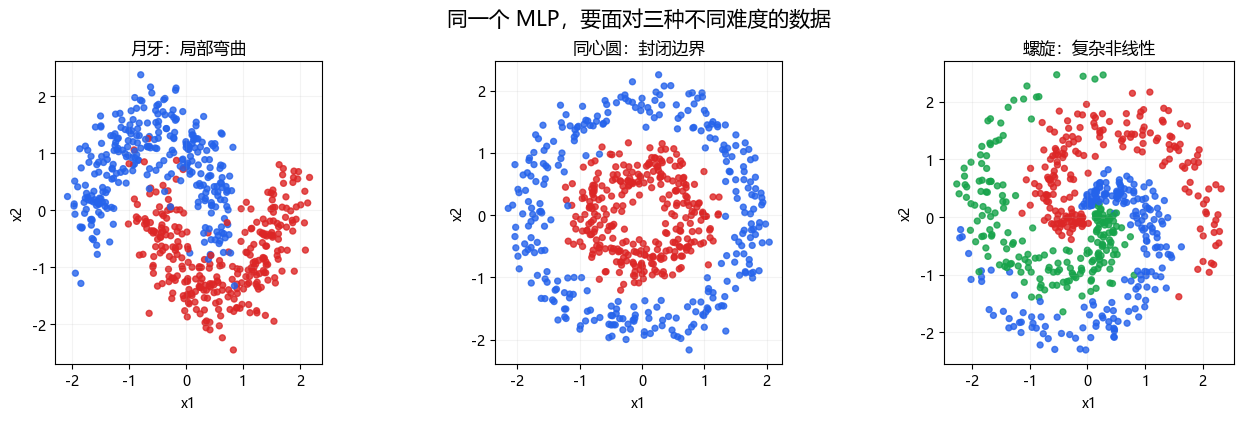

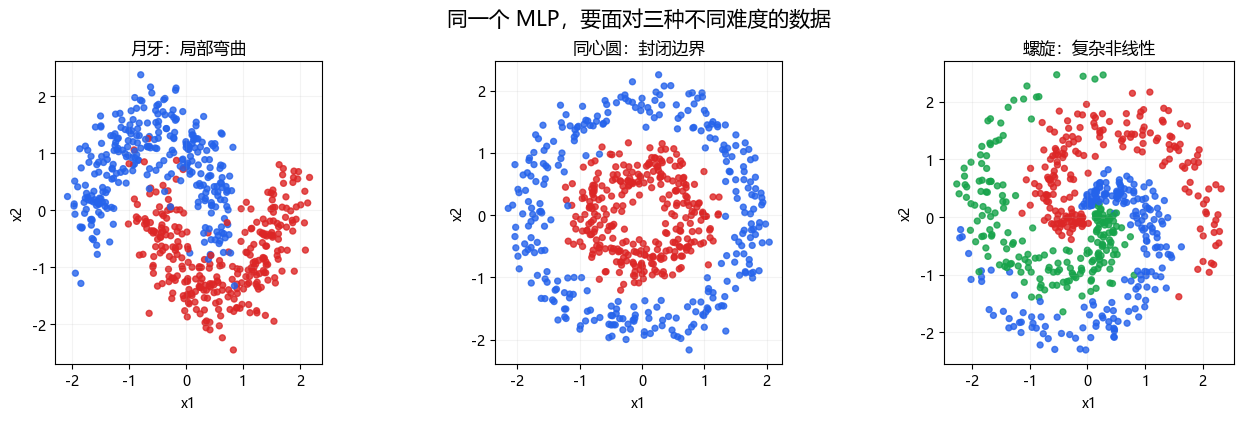

In [3]:
# 这里只生成数据和图形，不启动训练；先从几何形状判断任务难度。
plot_dataset_gallery(seed=SEED)

## 3. 基线模型：观察边界怎样长出来

基线使用两个 32 单元隐藏层、ReLU、Cross-Entropy 和 Adam。最后一层输出的是 **raw logits**，因为 `CrossEntropyLoss` 内部已经包含数值稳定的 LogSoftmax。

运行前先预测：Epoch 0 的随机边界是什么样？前几个 epoch 会先学会大轮廓还是细节？

In [ ]:
# 第一步：创建不可变基线配置，后续所有对照都从它派生。
baseline = base_config(dataset=DATASET, mode=MODE, seed=SEED, device=DEVICE)
# 第二步：只生成一次数据；重复使用同一划分才能进行公平比较。
data = make_dataset(
    baseline.dataset, baseline.n_samples, baseline.noise, baseline.seed
)
# 第三步：训练并记录 loss、accuracy、gradient norm 和关键 epoch 快照。
result = train_experiment(baseline, data=data)
# 第四步：核对模型结构，以及一个小批次在前向传播中的形状。
example_x = data.x_train[:4].to(next(result.model.parameters()).device)
with torch.no_grad():
    example_logits = result.model(example_x)
print(result.model)
print(f'形状检查：X={tuple(example_x.shape)} -> logits={tuple(example_logits.shape)}')
# 第五步：先查看数值摘要，再结合后面的图形解释。
print_result_table([result])

In [ ]:
# 六个训练阶段放在同一张图中：颜色含义和坐标范围保持一致。
plot_training_story(result)

In [ ]:
# 大叉号标出测试集误判点；右侧三图分别回答收敛、泛化和梯度问题。
plot_final_diagnosis(result)

## 4. 单变量对照：只替换激活函数

三列使用相同数据划分、隐藏层、损失函数、优化器、学习率和随机种子，只把 ReLU 换成 Tanh 或 Sigmoid。

**中心问题：** 如果 Sigmoid 的梯度越来越小，loss 与 decision boundary 会出现什么共同现象？

<details><summary>观察曲线后展开常见误区</summary>

“Sigmoid 一定不能训练”并不准确。它在深层网络或饱和区更容易产生小梯度，但具体表现还受初始化、深度和数据影响。

</details>

In [ ]:
# run_comparison 会复用同一数据，并把随机种子和其他组件保持不变。
activation_results = run_comparison('activation', baseline)
print_result_table(activation_results)
# 每列对应一种激活函数；每行对应同一种证据，便于横向比较。
plot_comparison(activation_results, '激活函数对比：非线性形状如何影响学习')

## 5. 损失函数：合法不等于最合适

Cross-Entropy 直接接收 logits。为了让 MSE 的比较在数学上成立，代码先把 logits 变成类别概率，再与 one-hot 标签比较；绝不能直接把类别编号 0、1、2 当成连续数值回归。

**预测题：** 两个方法即使最终准确率接近，它们的收敛速度和梯度曲线是否一定相同？

In [ ]:
# 两个配置使用相同 logits；core.py 内部负责匹配合法的目标表示。
loss_results = run_comparison('loss', baseline)
print_result_table(loss_results)
# 不只比较最终 accuracy，还要观察收敛速度与梯度大小。
plot_comparison(loss_results, '损失函数对比：分类目标应该怎样表达')

## 6A. 配置替换与参数预算挑战

先只修改下面标出的 5 行。每次修改一行并记录结果；默认值可以直接运行，因此整本 Notebook 始终支持 Run All。

In [ ]:
# ===== 动手修改区：只改下面 5 行 =====
practice_hidden_sizes = (16, 16)  # 例：(8, 8)、(32, 32)
practice_activation = 'tanh'       # relu / tanh / sigmoid
practice_optimizer = 'adam'        # sgd / momentum / adam
practice_dropout = 0.0             # 0.0 到 0.8 之间
practice_learning_rate = 0.02      # 建议从 0.001 到 0.1 之间尝试
# ===== 动手修改区结束 =====

challenge = replace(
    baseline,
    name='练习配置',
    hidden_sizes=practice_hidden_sizes,
    activation=practice_activation,
    optimizer=practice_optimizer,
    dropout=practice_dropout,
    learning_rate=practice_learning_rate,
)
challenge_result = train_experiment(challenge, data=data)
print_result_table([challenge_result])
print('参数预算是否通过：', challenge_result.parameter_count <= 2000)
accuracy_delta = challenge_result.final_test_accuracy - result.final_test_accuracy
print(f'相对基线的测试准确率变化：{accuracy_delta:+.1%}')
plot_final_diagnosis(challenge_result)

## 6B. 新增组件

任选一个任务，然后重新运行第 6A 节：

1. 在 `core.py` 的 `_activation()` 中增加 `"leaky_relu": nn.LeakyReLU`；
2. 在 `validate_config()` 和 `_make_optimizer()` 中增加 `rmsprop`；
3. 将新增组件与最接近的已有组件进行单变量对照。

修改后先运行 `python test_mlp_smoke.py`。如果还要从命令行选择新组件，再同步更新 `demo.py` 中对应参数的 `choices`。

## 6C. 修改模型结构

在 `core.py` 的 `MLP` 类中调整隐藏层，或增加 `BatchNorm1d`。修改前先写出预期张量形状；修改后打印模型，确认输出仍为 `[batch, n_classes]` 的 raw logits。

## 7. 实验记录

| 实验 | 我的预测 | 唯一修改项 | seed | 参数量 | 基线结果 | 新结果 | 图形证据 | 结论 |
|---|---|---|---:|---:|---:|---:|---|---|
| 1 |  |  | 42 |  |  |  |  |  |
| 2 |  |  | 42 |  |  |  |  |  |
| 3 |  |  | 42 |  |  |  |  |  |

> 本次只修改了 ______。从 ______ 图可以看到 ______。在当前数据、随机种子和训练轮数下，结果支持 / 不支持 ______。

## 8. 小结与离堂问题

- 决策边界展示模型**学到了什么形状**；loss 展示目标下降；accuracy 展示分类结果；gradient norm 展示更新信号。
- 更深、更宽或 Dropout 更大都不保证更好，结论必须依赖受控实验。
- CPU 与 GPU 的最后几位数值可能不同；我们比较稳定趋势，不比较最后一位小数。

**离堂问题：** 如果训练准确率继续上升，而测试准确率开始下降，你下一次只会修改哪一个组件？为什么？